<a href="https://colab.research.google.com/github/dtoralg/INESDI_Data-Science_ML_IA/blob/main/%5B05%5D%20-%20Arboles%20de%20decision/%5B05.1%5D%20-%20WS%20PT/01_Arboles_Decision_IBM_Telco_PT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 Árboles de Decisión — IBM Telco Customer Churn

> **Módulo:** Data Analytics: Data Science, Machine Learning e Inteligencia Artificial  
> **Máster:** FP en Business Analytics e Inteligencia Artificial — INESDI Business Techschool  
> **Profesor:** Álvaro López  
> **Dataset:** IBM Telco Customer Churn (dataset real, compartido por todos)  
> **Entorno:** Google Colab ✅

---

## 🎯 ¿Qué vamos a aprender?

Al terminar este notebook serás capaz de:
- Cargar y limpiar un dataset real de empresa
- Entrenar tu primer árbol de decisión para clasificación
- Visualizar el árbol e interpretar sus reglas de negocio
- Detectar y corregir el **overfitting**
- Evaluar el modelo con métricas reales: Accuracy, F1, ROC-AUC
- Usar **SHAP** para explicar cada predicción a un stakeholder

---

## 🏢 El caso de negocio

Somos el equipo de **retención de clientes** de una empresa de telecomunicaciones.

**El problema:** cada mes perdemos clientes sin saber de antemano quiénes se van a ir.
Recuperar un cliente que ya se fue cuesta **5-7x más** que retener uno que está a punto de irse.

**Nuestro objetivo:** construir un modelo que identifique qué clientes tienen alta probabilidad
de darse de baja, para que el equipo comercial los contacte **antes** de que se vayan.

```
Dataset:  7.043 clientes reales de IBM con 20 variables
Target:   Churn — Yes (se fue) / No (se quedó)
Tipo:     Clasificación binaria
```

---
## 📦 1. Instalación y librerías

Todas las librerías vienen preinstaladas en Colab **excepto SHAP**.
Ejecuta esta celda primero — tardará ~30 segundos.

In [ ]:
# Instalar SHAP (solo necesario la primera vez en Colab)
!pip install shap -q

# ── Librerías ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

import shap
shap.initjs()

# ── Estilo visual ────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

C_CHURN    = '#E53935'  # rojo  → se fue
C_NOCHURN  = '#1E88E5'  # azul  → se quedó
C_NEUTRAL  = '#00BCD4'  # cyan  → neutral

print('✅ Todo listo!')

✅ Todo listo!


---
## 📂 2. Cargamos el dataset real — IBM Telco Customer Churn

Cargamos directamente desde GitHub con una URL pública.
**Todos obtenéis exactamente los mismos datos** — no hay aleatoriedad en este paso.

### Variables del dataset

| Grupo | Variables |
|---|---|
| **Demografía** | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| **Cuenta** | `tenure` (meses), `Contract`, `PaperlessBilling`, `PaymentMethod` |
| **Servicios** | `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| **Facturación** | `MonthlyCharges`, `TotalCharges` |
| **🎯 Target** | **`Churn`** — Yes / No |

In [ ]:
# ── Carga directa desde GitHub (URL pública, siempre disponible) ─────
URL = ('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d'
       '/master/data/Telco-Customer-Churn.csv')

df = pd.read_csv(URL)

print(f'✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'   Tasa de churn:   {(df["Churn"]=="Yes").mean():.1%}')
df.head()

✅ Dataset cargado: 7,043 filas × 21 columnas
   Tasa de churn:   26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# ── Opción B: cargar desde archivo local (si no hay internet) ────────────
# 1. Descarga el CSV y súbelo a Colab con el botón 📁 del panel izquierdo
# 2. Comenta la Opción A y descomenta esta línea:
# from google.colab import files
# uploaded = files.upload()           # abre el selector de archivos
# df = pd.read_csv('Telco-Customer-Churn.csv')

# ── Opción C: cargar desde Google Drive ──────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/Telco-Customer-Churn.csv')

---
## 🧹 3. Limpieza de datos

Los datos reales siempre tienen imperfecciones. Antes de modelar, debemos corregirlas.
Este dataset tiene **dos problemas conocidos** que hay que resolver:

1. `TotalCharges` se cargó como texto (hay espacios vacíos disfrazados de valores)
2. `Churn` es `Yes`/`No` → necesitamos convertirlo a `1`/`0`

In [ ]:
# ── Diagnóstico inicial ──────────────────────────────────────────────
print('Tipos de datos:')
print(df.dtypes[['TotalCharges', 'Churn', 'SeniorCitizen']])
print()

# TotalCharges: convertir a numérico (los espacios se convierten en NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# ¿Cuántos NaN hay?
n_nan = df['TotalCharges'].isna().sum()
print(f'Filas con TotalCharges vacío: {n_nan}')
print('(Son clientes nuevos con tenure=0 — no han recibido ninguna factura aún)')

# Eliminar esas filas (son 11 de 7043 → impacto mínimo)
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)

# ── Convertir Churn a numérico ────────────────────────────────────────
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# ── Eliminar columna ID (no es una variable predictora) ──────────────
df = df.drop(columns=['customerID'])

print(f'\n✅ Dataset limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'   Churn: {df["Churn"].sum():,} clientes perdidos ({df["Churn"].mean():.1%})')
df.info()

Tipos de datos:
TotalCharges     object
Churn            object
SeniorCitizen     int64
dtype: object

Filas con TotalCharges vacío: 11
(Son clientes nuevos con tenure=0 — no han recibido ninguna factura aún)

✅ Dataset limpio: 7,032 filas × 20 columnas
   Churn: 1,869 clientes perdidos (26.6%)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-n

---
## 🔍 4. Exploración de datos (EDA)

Antes de modelar, siempre exploramos los datos.
Queremos entender qué variables parecen más relacionadas con el churn.

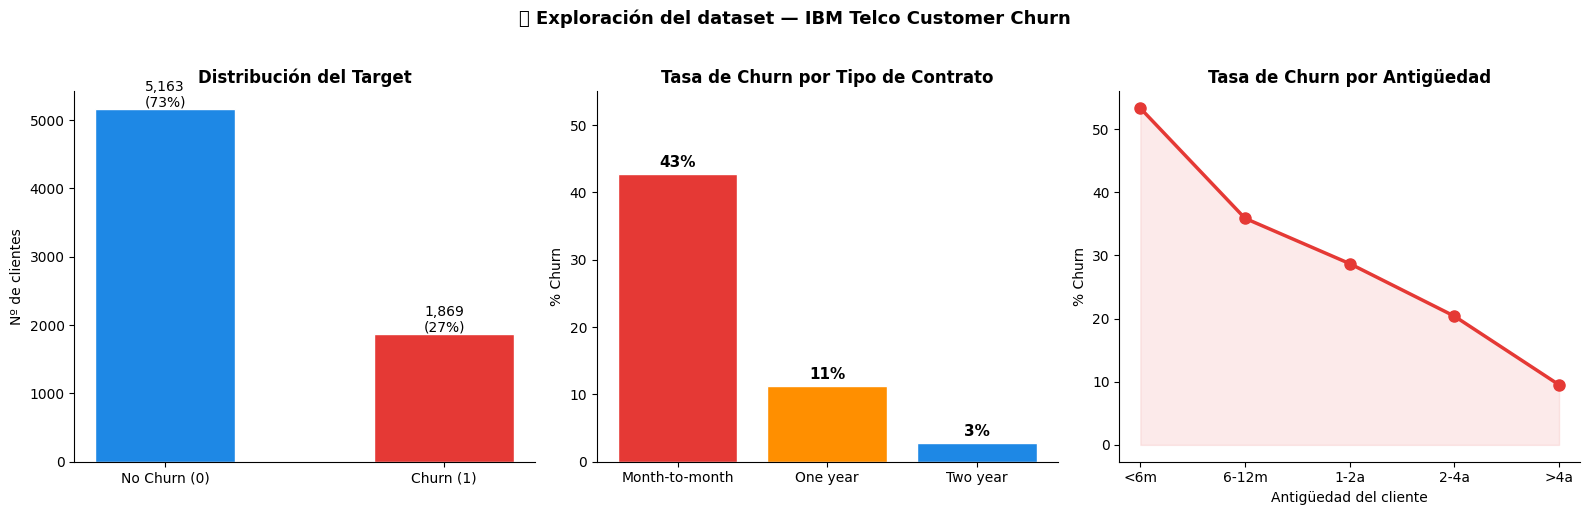


💡 Patrones clave en los datos reales:
  • Contratos mes a mes:  43% de churn
  • Contratos 2 años:     3% de churn
  • Clientes <6 meses:    53% de churn — el doble que la media


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Gráfico 1: Distribución del target ───────────────────────────────
counts = df['Churn'].value_counts()
axes[0].bar(['No Churn (0)', 'Churn (1)'], counts.values,
            color=[C_NOCHURN, C_CHURN], width=0.5, edgecolor='white')
axes[0].set_title('Distribución del Target', fontweight='bold')
axes[0].set_ylabel('Nº de clientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v:,}\n({v/len(df):.0%})',
                ha='center', fontsize=10)

# ── Gráfico 2: Churn por tipo de contrato ────────────────────────────
churn_contrato = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
axes[1].bar(churn_contrato.index, churn_contrato.values * 100,
            color=[C_CHURN, '#FF8F00', C_NOCHURN], edgecolor='white')
axes[1].set_title('Tasa de Churn por Tipo de Contrato', fontweight='bold')
axes[1].set_ylabel('% Churn')
axes[1].set_ylim(0, 55)
for i, (idx, v) in enumerate(churn_contrato.items()):
    axes[1].text(i, v*100 + 1, f'{v:.0%}', ha='center',
                fontweight='bold', fontsize=11)

# ── Gráfico 3: Churn vs. Antigüedad (tenure) ─────────────────────────
df['grupo_tenure'] = pd.cut(df['tenure'],
                             bins=[0,6,12,24,48,72],
                             labels=['<6m','6-12m','1-2a','2-4a','>4a'])
churn_tenure = df.groupby('grupo_tenure', observed=True)['Churn'].mean()
axes[2].plot(churn_tenure.index, churn_tenure.values*100,
             color=C_CHURN, marker='o', linewidth=2.5, markersize=8)
axes[2].fill_between(range(len(churn_tenure)),
                      churn_tenure.values*100, alpha=0.1, color=C_CHURN)
axes[2].set_title('Tasa de Churn por Antigüedad', fontweight='bold')
axes[2].set_ylabel('% Churn')
axes[2].set_xlabel('Antigüedad del cliente')

plt.suptitle('📊 Exploración del dataset — IBM Telco Customer Churn',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n💡 Patrones clave en los datos reales:')
month2month = df[df['Contract']=='Month-to-month']['Churn'].mean()
twoyear     = df[df['Contract']=='Two year']['Churn'].mean()
new_clients = df[df['tenure'] <= 6]['Churn'].mean()
print(f'  • Contratos mes a mes:  {month2month:.0%} de churn')
print(f'  • Contratos 2 años:     {twoyear:.0%} de churn')
print(f'  • Clientes <6 meses:    {new_clients:.0%} de churn — el doble que la media')

---
## 🏗️ 5. Preparación del dataset para el modelo

scikit-learn solo trabaja con números.
Tenemos muchas columnas categóricas (`Yes`/`No`, `Male`/`Female`, etc.) que hay que codificar.

> **Label Encoding:** convierte cada categoría en un número entero.
> `No` → 0, `Yes` → 1 / `Female` → 0, `Male` → 1 / etc.
> Funciona bien para árboles de decisión porque no asumen ningún orden entre categorías.

In [ ]:
df_model = df.drop(columns=['grupo_tenure']).copy()

# Identificar columnas categóricas (texto) a codificar
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f'Columnas categóricas a codificar ({len(cat_cols)}):  {cat_cols}')

# Label Encoding para cada columna categórica
le = LabelEncoder()
encodings = {}
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    encodings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# Mostrar cómo quedaron las más relevantes
print('\nCodificación de variables clave:')
for col in ['Contract', 'InternetService', 'PaymentMethod']:
    print(f'  {col}: {encodings[col]}')

# ── Separar features y target ─────────────────────────────────────────
FEATURES = [c for c in df_model.columns if c != 'Churn']
X = df_model[FEATURES]
y = df_model['Churn']

# ── División train / test ─────────────────────────────────────────────
# stratify=y → mantiene la misma proporción de churn en ambos splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape[0]:,} clientes  |  Test: {X_test.shape[0]:,} clientes')
print(f'Churn en train: {y_train.mean():.1%}  |  Churn en test: {y_test.mean():.1%}')
print('✅ Proporciones iguales — stratify funciona correctamente')

Columnas categóricas a codificar (15):  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Codificación de variables clave:
  Contract: {'Month-to-month': np.int64(0), 'One year': np.int64(1), 'Two year': np.int64(2)}
  InternetService: {'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}
  PaymentMethod: {'Bank transfer (automatic)': np.int64(0), 'Credit card (automatic)': np.int64(1), 'Electronic check': np.int64(2), 'Mailed check': np.int64(3)}

Train: 5,625 clientes  |  Test: 1,407 clientes
Churn en train: 26.6%  |  Churn en test: 26.6%
✅ Proporciones iguales — stratify funciona correctamente


---
## 🌳 6. Nuestro primer árbol de decisión

### ¿Cómo aprende un árbol de decisión?

El árbol recorre los datos y busca **la pregunta que mejor separa** churns de no-churns.

```
¿Tiene contrato mensual?
      ├── SÍ → ¿tenure < 12 meses?
      │             ├── SÍ → CHURN       (probabilidad 68%)
      │             └── NO → Continuar...
      └── NO → NO CHURN                  (probabilidad 8%)
```

Para elegir la mejor pregunta usa el **índice Gini**:
- `Gini = 0` → nodo puro (todos churn o todos no-churn) ✅
- `Gini = 0.5` → máximo desorden (mitad y mitad) ❌

El árbol elige siempre la pregunta que más reduce el Gini.

### Empezamos sin restricciones — para ver el problema

## Pequeña explicación de Gini

El índice Gini mide el "desorden" de un grupo. La pregunta que responde es: si cojo un cliente al azar de este grupo, ¿qué probabilidad hay de que esté mal clasificado?

Gini = 0 → el grupo es puro. Todos son churn, o todos son no-churn. Perfecto.
Gini = 0.5 → máximo desorden. Mitad churn, mitad no-churn. Inútil.

La fórmula es Gini = 1 − (p_churn² + p_nochurn²)

Ejemplo:

Grupo A: 100 clientes, 98 churn, 2 no-churn
→ Gini ≈ 0.04  (casi puro, muy bueno)

Grupo B: 100 clientes, 50 churn, 50 no-churn
→ Gini = 0.50  (total desorden, no sirve de nada)

Grupo C: 100 clientes, 80 churn, 20 no-churn
→ Gini = 0.32  (bastante bueno)

In [ ]:
# ── Árbol SIN restricciones ───────────────────────────────────────────
# max_depth=None → el árbol crece hasta que cada hoja tenga 1 solo cliente
dt_baseline = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_baseline.fit(X_train, y_train)

acc_train = accuracy_score(y_train, dt_baseline.predict(X_train))
acc_test  = accuracy_score(y_test,  dt_baseline.predict(X_test))

print('📊 ÁRBOL SIN RESTRICCIONES')
print(f'   Accuracy en TRAIN: {acc_train:.1%}  ← el modelo vio estos datos al entrenar')
print(f'   Accuracy en TEST:  {acc_test:.1%}  ← datos que nunca ha visto')
print(f'   Profundidad del árbol: {dt_baseline.get_depth()}')
print(f'   Número de hojas:       {dt_baseline.get_n_leaves():,}')
print()
print('⚠️  Train casi perfecto, Test bastante peor → OVERFITTING')
print('   El árbol memorizó los 5.634 clientes de train en lugar de aprender patrones.')

📊 ÁRBOL SIN RESTRICCIONES
   Accuracy en TRAIN: 99.9%  ← el modelo vio estos datos al entrenar
   Accuracy en TEST:  71.3%  ← datos que nunca ha visto
   Profundidad del árbol: 26
   Número de hojas:       1,093

⚠️  Train casi perfecto, Test bastante peor → OVERFITTING
   El árbol memorizó los 5.634 clientes de train en lugar de aprender patrones.


### 🚨 El problema: overfitting (sobreajuste)

El árbol sin límite de profundidad acaba teniendo **una hoja por cada cliente**.
Memoriza perfectamente el train, pero cuando llega un cliente nuevo... falla.

> **Analogía:** un estudiante que memoriza todas las respuestas del libro de ejercicios.
> Saca 10 en los ejercicios que ya conoce, pero falla en el examen con preguntas nuevas.

La solución: **controlar la complejidad del árbol** con hiperparámetros.
Lo haremos en la sección 8. Antes, aprendemos a visualizarlo.

---
## 👁️ 7. Visualizando el árbol — la gran ventaja

La mayor ventaja de los árboles sobre otros modelos:
**puedes mostrar la lógica completa a un directivo**.
No es una caja negra — son preguntas que cualquiera puede entender.

Entrenamos un árbol limitado (`max_depth=3`) para que el dibujo sea legible:

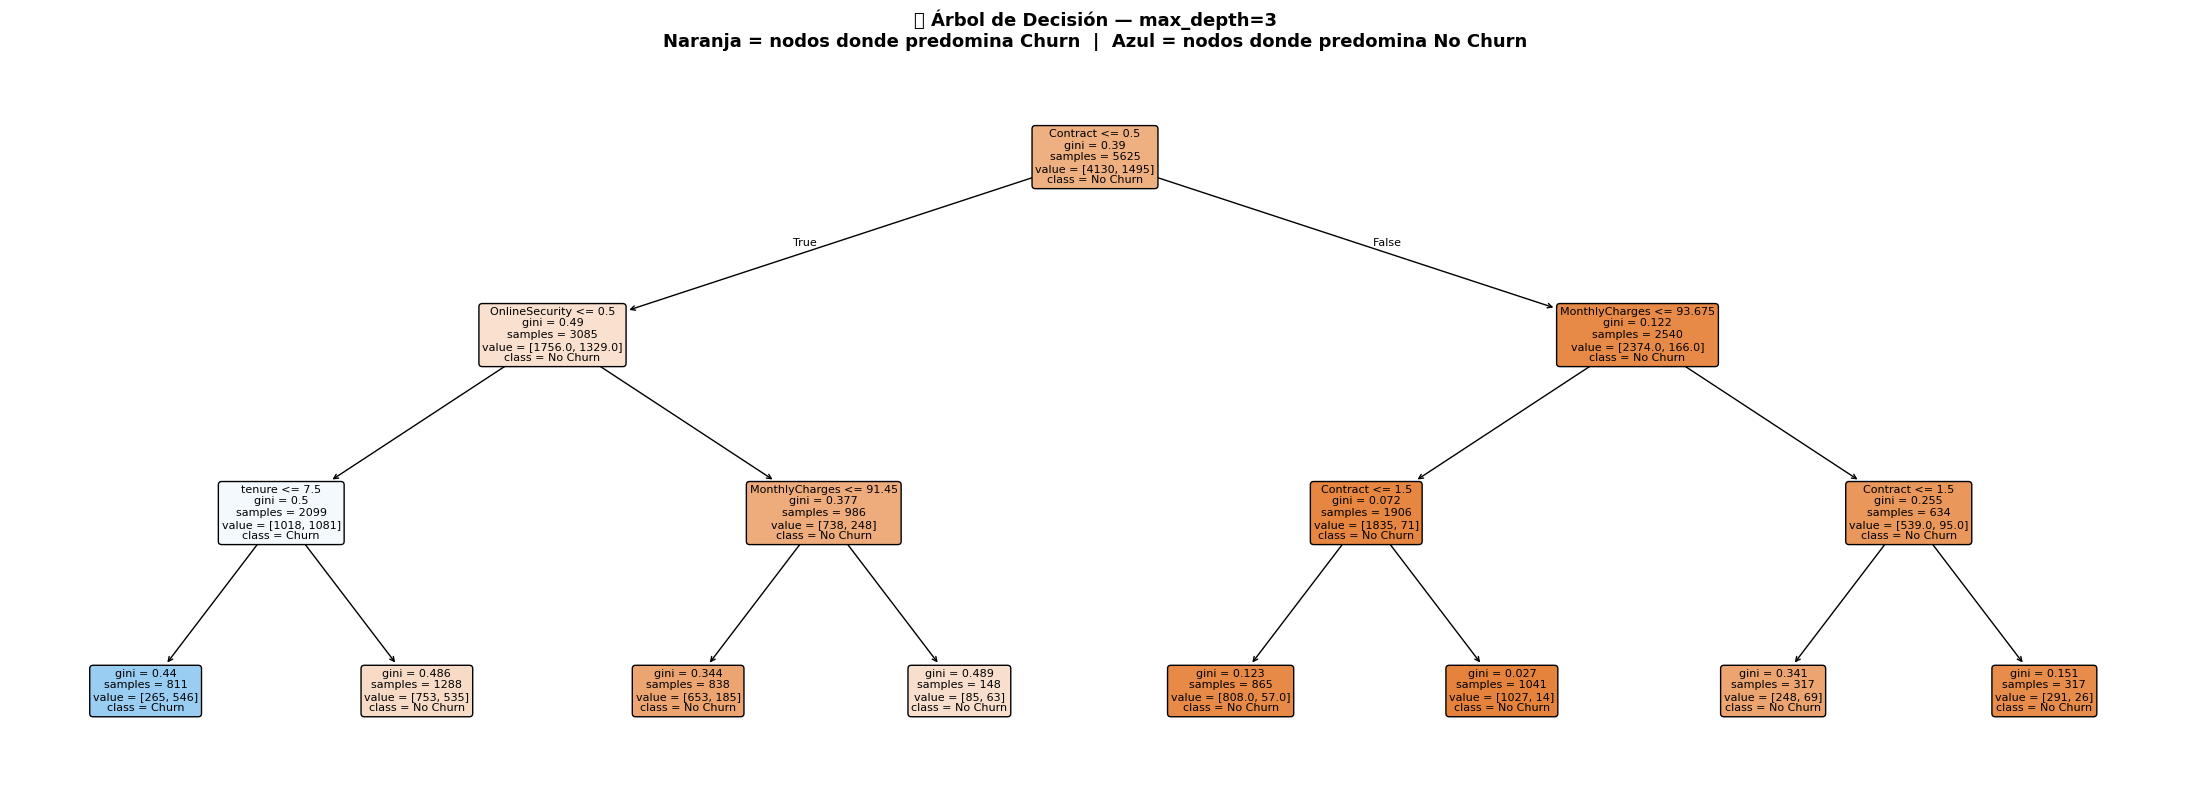


📋 Estructura del árbol (texto):
|--- Contract <= 0.50
|   |--- OnlineSecurity <= 0.50
|   |   |--- tenure <= 7.50
|   |   |   |--- class: 1
|   |   |--- tenure >  7.50
|   |   |   |--- class: 0
|   |--- OnlineSecurity >  0.50
|   |   |--- MonthlyCharges <= 91.45
|   |   |   |--- class: 0
|   |   |--- MonthlyCharges >  91.45
|   |   |   |--- class: 0
|--- Contract >  0.50
|   |--- MonthlyCharges <= 93.67
|   |   |--- Contract <= 1.50
|   |   |   |--- class: 0
|   |   |--- Contract >  1.50
|   |   |   |--- class: 0
|   |--- MonthlyCharges >  93.67
|   |   |--- Contract <= 1.50
|   |   |   |--- class: 0
|   |   |--- Contract >  1.50
|   |   |   |--- class: 0



In [ ]:
# Árbol reducido para visualizar
dt_visual = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dt_visual.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_visual,
    feature_names=FEATURES,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
    proportion=False,
)
ax.set_title(
    '🌳 Árbol de Decisión — max_depth=3\n'
    'Naranja = nodos donde predomina Churn  |  Azul = nodos donde predomina No Churn',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
plt.show()

# Versión texto — más útil para copiar a un informe
print('\n📋 Estructura del árbol (texto):')
print(export_text(dt_visual, feature_names=FEATURES))

### 🔍 Cómo leer un nodo del árbol

```
Contract <= 0.5          ← la PREGUNTA (punto de corte aprendido automáticamente)
gini = 0.387             ← desorden del nodo  (0 = puro,  0.5 = máximo desorden)
samples = 5634           ← clientes que llegan a este nodo
value = [4148, 1486]     ← [No Churn, Churn]
class = No Churn         ← clase mayoritaria → predicción si paramos aquí
```

> **Contract <= 0.5** significa: ¿el código de contrato es 0 (Month-to-month)?
> Recuerda que codificamos: `{'Month-to-month': 0, 'One year': 1, 'Two year': 2}`

**Para predecir un cliente nuevo:** seguimos el árbol respondiendo las preguntas
hasta llegar a una hoja → la clase mayoritaria de esa hoja es nuestra predicción.

---
## 🔧 8. Controlando el overfitting: hiperparámetros

Los **hiperparámetros** son los ajustes que tú configuras **antes** de entrenar.
El modelo no los aprende solo — tú decides su valor.

| Hiperparámetro | Qué controla | Valor bajo → | Valor alto → |
|---|---|---|---|
| `max_depth` | Profundidad máxima del árbol | Árbol simple (underfitting) | Árbol complejo (overfitting) |
| `min_samples_split` | Mínimo de muestras para dividir un nodo | Más divisiones | Menos divisiones |
| `min_samples_leaf` | Mínimo de muestras en cada hoja | Hojas pequeñas | Hojas grandes |

### La curva de validación — encontrando el punto óptimo

Vamos a probar diferentes valores de `max_depth` y ver el impacto en train y test:

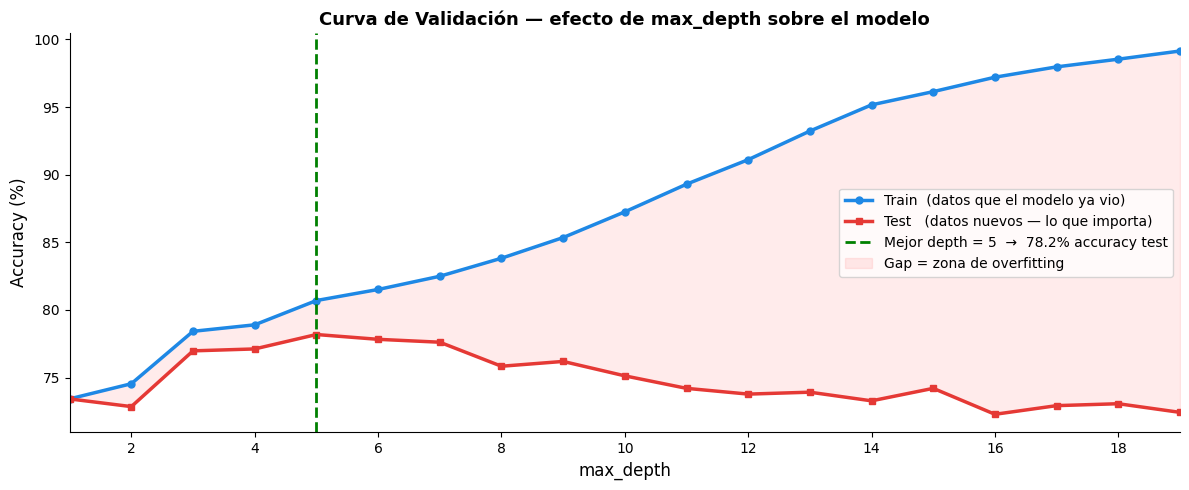


✅ Profundidad óptima: max_depth = 5  →  78.2% accuracy en test


In [ ]:
depths      = range(1, 20)
acc_trains  = []
acc_tests   = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    acc_trains.append(accuracy_score(y_train, dt.predict(X_train)))
    acc_tests.append(accuracy_score(y_test,  dt.predict(X_test)))

best_depth = list(depths)[np.argmax(acc_tests)]
best_acc   = max(acc_tests)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(depths, [a*100 for a in acc_trains],
        color=C_NOCHURN, lw=2.5, marker='o', ms=5,
        label='Train  (datos que el modelo ya vio)')
ax.plot(depths, [a*100 for a in acc_tests],
        color=C_CHURN, lw=2.5, marker='s', ms=5,
        label='Test   (datos nuevos — lo que importa)')
ax.axvline(best_depth, color='green', ls='--', lw=2,
           label=f'Mejor depth = {best_depth}  →  {best_acc:.1%} accuracy test')
ax.fill_between(depths,
                [a*100 for a in acc_trains],
                [a*100 for a in acc_tests],
                alpha=0.08, color='red', label='Gap = zona de overfitting')

ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Curva de Validación — efecto de max_depth sobre el modelo',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(1, 19)

plt.tight_layout()
plt.show()
print(f'\n✅ Profundidad óptima: max_depth = {best_depth}  →  {best_acc:.1%} accuracy en test')

---
## 📈 9. Evaluación del modelo

El Accuracy solo no es suficiente. Si el 73% de los clientes no hacen churn,
un modelo que siempre predice 'No Churn' tiene 73% de Accuracy... pero es inútil.

### Las métricas que importan en un problema de churn

| Métrica | Pregunta que responde | Importancia en churn |
|---|---|---|
| **Precision** | De los que predije como churn, ¿cuántos realmente lo eran? | Media — evita llamadas innecesarias |
| **Recall** | De todos los churns reales, ¿cuántos detecté? | **Alta** — no queremos perder clientes |
| **F1-Score** | Balance entre Precision y Recall | Alta — métrica resumen |
| **ROC-AUC** | ¿Cómo separa el modelo las dos clases? | Alta — independiente del umbral |

> 💡 En retención de clientes, **el error más caro es el Falso Negativo**:
> predecir que un cliente NO se va cuando SÍ se va. No le llamas y le pierdes.

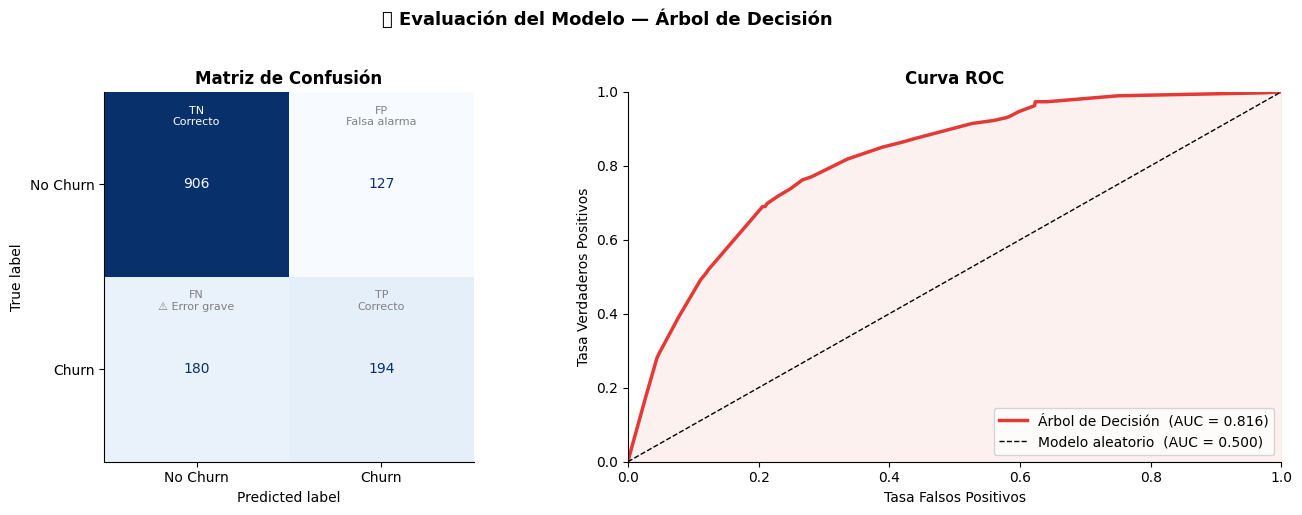

📋 REPORTE DE MÉTRICAS
              precision    recall  f1-score   support

    No Churn       0.83      0.88      0.86      1033
       Churn       0.60      0.52      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407

ROC-AUC : 0.816

📌 Interpretación de negocio:
  ✅ 906 clientes que no iban a irse — predijimos bien (TN)
  ⚠️  127 clientes que no iban a irse — les llamamos igual (FP) → coste de llamada
  🚨 180 clientes que SÍ se fueron — no los detectamos (FN) → cliente perdido
  ✅ 194 clientes en riesgo — detectados y contactados a tiempo (TP)


In [ ]:
# Árbol óptimo con la mejor profundidad + regularización adicional
dt_optimo = DecisionTreeClassifier(
    criterion='gini',
    max_depth=best_depth,
    min_samples_split=20,    # un nodo necesita ≥20 muestras para dividirse
    min_samples_leaf=10,     # cada hoja necesita ≥10 muestras
    random_state=42
)
dt_optimo.fit(X_train, y_train)

y_pred = dt_optimo.predict(X_test)
y_prob = dt_optimo.predict_proba(X_test)[:, 1]

# ── Matriz de confusión + Curva ROC ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Matriz de Confusión', fontsize=12, fontweight='bold')
# Etiquetas de los 4 cuadrantes
for (i, j), label in [((0,0),'TN\nCorrecto'), ((0,1),'FP\nFalsa alarma'),
                        ((1,0),'FN\n⚠ Error grave'), ((1,1),'TP\nCorrecto')]:
    axes[0].text(j, i-0.32, label, ha='center', fontsize=8,
                color='white' if cm[i,j] > cm.max()*0.5 else 'grey')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color=C_CHURN, lw=2.5,
             label=f'Árbol de Decisión  (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Modelo aleatorio  (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.07, color=C_CHURN)
axes[1].set(xlabel='Tasa Falsos Positivos', ylabel='Tasa Verdaderos Positivos',
            title='Curva ROC', xlim=[0,1], ylim=[0,1])
axes[1].legend()
axes[1].set_title('Curva ROC', fontsize=12, fontweight='bold')

plt.suptitle('📊 Evaluación del Modelo — Árbol de Decisión',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Resumen de métricas
tn, fp, fn, tp = cm.ravel()
print('📋 REPORTE DE MÉTRICAS')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print(f'ROC-AUC : {auc:.3f}')
print()
print('📌 Interpretación de negocio:')
print(f'  ✅ {tn:,} clientes que no iban a irse — predijimos bien (TN)')
print(f'  ⚠️  {fp:,} clientes que no iban a irse — les llamamos igual (FP) → coste de llamada')
print(f'  🚨 {fn:,} clientes que SÍ se fueron — no los detectamos (FN) → cliente perdido')
print(f'  ✅ {tp:,} clientes en riesgo — detectados y contactados a tiempo (TP)')

### Comparativa: Baseline vs. Árbol Óptimo

In [ ]:
y_pred_base = dt_baseline.predict(X_test)
y_prob_base = dt_baseline.predict_proba(X_test)[:,1]

print(f'  {"":32} {"BASELINE":>12} {"ÓPTIMO":>12}')
print('  ' + '-'*58)

filas = [
    ('Accuracy (test)',
     accuracy_score(y_test, y_pred_base),
     accuracy_score(y_test, y_pred)),
    ('F1 — clase Churn',
     f1_score(y_test, y_pred_base),
     f1_score(y_test, y_pred)),
    ('ROC-AUC',
     roc_auc_score(y_test, y_prob_base),
     roc_auc_score(y_test, y_prob)),
]
for nombre, v_base, v_opt in filas:
    mejora = '✅ mejora' if v_opt > v_base else '⬇'
    print(f'  {nombre:32} {v_base:>12.3f} {v_opt:>12.3f}  {mejora}')

print(f'  {"Profundidad":32} {dt_baseline.get_depth():>12} {dt_optimo.get_depth():>12}')
print(f'  {"Nº hojas":32} {dt_baseline.get_n_leaves():>12,} {dt_optimo.get_n_leaves():>12,}')
print()
print('💡 El árbol óptimo es mucho más simple y generaliza mejor.')
print('   Menos hojas = menos memorización = más capacidad de generalizar.')

                                       BASELINE       ÓPTIMO
  ----------------------------------------------------------
  Accuracy (test)                         0.713        0.782  ✅ mejora
  F1 — clase Churn                        0.482        0.558  ✅ mejora
  ROC-AUC                                 0.647        0.816  ✅ mejora
  Profundidad                                26            5
  Nº hojas                                1,093           31

💡 El árbol óptimo es mucho más simple y generaliza mejor.
   Menos hojas = menos memorización = más capacidad de generalizar.


---
## 🔎 10. SHAP — Explicando las predicciones

Tenemos un modelo que predice. Pero, **¿por qué predice lo que predice?**

**SHAP** (SHapley Additive exPlanations) calcula cuánto contribuyó **cada variable**
a la predicción de **cada cliente individual**.

> **Analogía:** después de ganar 3-1, SHAP te dice:
> *'El delantero aportó +2 goles, el centrocampo +1, pero la defensa −1 por un error'.*
> Sabes exactamente quién contribuyó qué al resultado.

Esto transforma una predicción opaca en algo explicable a tu director:
> *'El modelo asigna 78% de riesgo a este cliente porque tiene contrato mensual (+32%),
> lleva menos de 6 meses con nosotros (+18%) y ha llamado 4 veces a soporte (+12%)'*

| Valor SHAP | Significa |
|---|---|
| **Positivo (+)** | Esta variable **aumenta** la probabilidad de churn |
| **Negativo (−)** | Esta variable **reduce** la probabilidad de churn |
| **≈ 0** | Esta variable no influyó en esta predicción concreta |

In [ ]:
# Calcular valores SHAP para todo el test set
explainer   = shap.TreeExplainer(dt_optimo)
shap_values = explainer.shap_values(X_test)

# ── Compatibilidad entre versiones de SHAP ───────────────────────────────
# Versiones antiguas → shap_values es una lista [clase_0, clase_1]
# Versiones nuevas   → shap_values es un array 3D (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    shap_churn = shap_values[1]                  # lista → coger clase 1
else:
    shap_churn = shap_values[:, :, 1]            # array 3D → slice clase 1

print(f'Valores SHAP calculados: {shap_churn.shape[0]:,} clientes × {shap_churn.shape[1]} variables')
print(f'Tipo de salida SHAP: {type(shap_values).__name__}, shape: {np.array(shap_values).shape}')

Valores SHAP calculados: 1,407 clientes × 19 variables
Tipo de salida SHAP: ndarray, shape: (1407, 19, 2)


### 📊 10.1 Summary Plot — ¿Qué variables importan más en general?

- **Eje Y:** variables ordenadas de mayor a menor importancia
- **Eje X:** valor SHAP (derecha = aumenta churn, izquierda = lo reduce)
- **Color del punto:** valor alto de la variable (rojo) o valor bajo (azul)

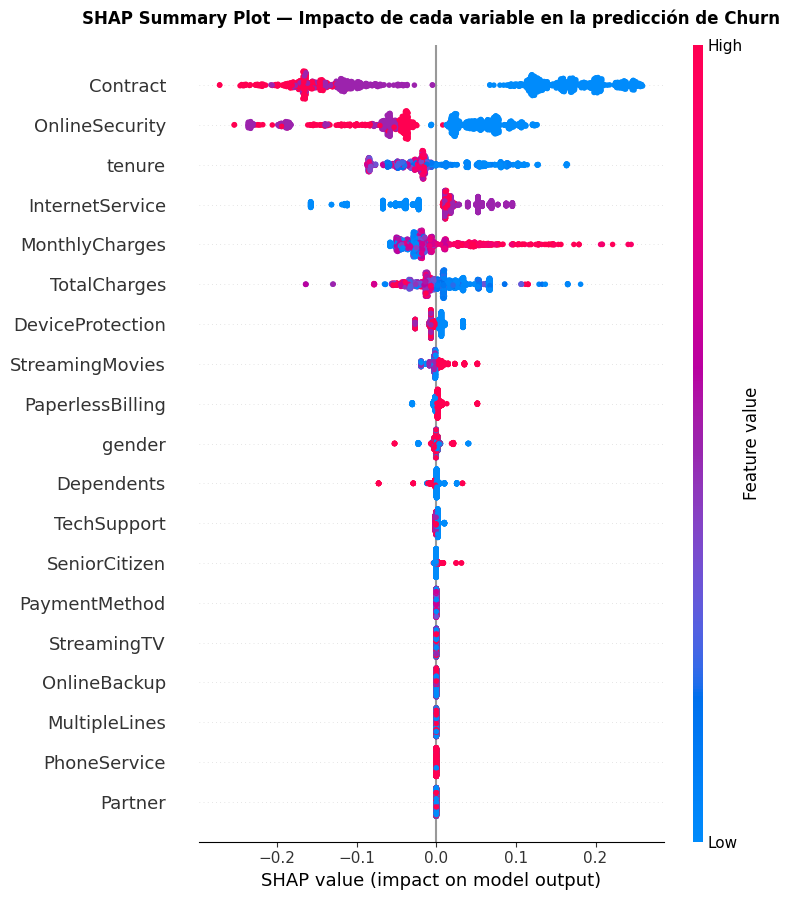

In [ ]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    np.array(shap_churn),      # ← conversión explícita a numpy array
    X_test,
    feature_names=FEATURES,
    plot_type='dot',
    show=False
)
plt.title('SHAP Summary Plot — Impacto de cada variable en la predicción de Churn',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 🔍 10.2 Waterfall Plot — Explicando un cliente concreto

El Waterfall responde: *'¿Por qué el modelo dice que ESTE cliente específico va a hacer churn?'*

In [ ]:
# Seleccionar un cliente con alta probabilidad de churn
y_prob_opt = dt_optimo.predict_proba(X_test)[:, 1]
high_risk   = np.where(y_prob_opt >= 0.70)[0]
idx         = high_risk[0] if len(high_risk) > 0 else np.argmax(y_prob_opt)

prob_pred = y_prob_opt[idx]
real_val  = y_test.iloc[idx]

print(f'🎯 Cliente analizado (índice de test: {idx})')
print(f'   Probabilidad de churn según el modelo: {prob_pred:.1%}')
print(f'   ¿Realmente hizo churn?                 {"SÍ ✅" if real_val==1 else "NO ❌"}')
print()
print('📋 Sus características:')
row = X_test.iloc[idx]
for feat, val in zip(FEATURES, row.values):
    print(f'   {feat:22} = {val}')

🎯 Cliente analizado (índice de test: 1)
   Probabilidad de churn según el modelo: 82.6%
   ¿Realmente hizo churn?                 NO ❌

📋 Sus características:
   gender                 = 0.0
   SeniorCitizen          = 0.0
   Partner                = 0.0
   Dependents             = 0.0
   tenure                 = 7.0
   PhoneService           = 1.0
   MultipleLines          = 2.0
   InternetService        = 1.0
   OnlineSecurity         = 0.0
   OnlineBackup           = 2.0
   DeviceProtection       = 0.0
   TechSupport            = 0.0
   StreamingTV            = 0.0
   StreamingMovies        = 0.0
   Contract               = 0.0
   PaperlessBilling       = 1.0
   PaymentMethod          = 0.0
   MonthlyCharges         = 78.55
   TotalCharges           = 522.95


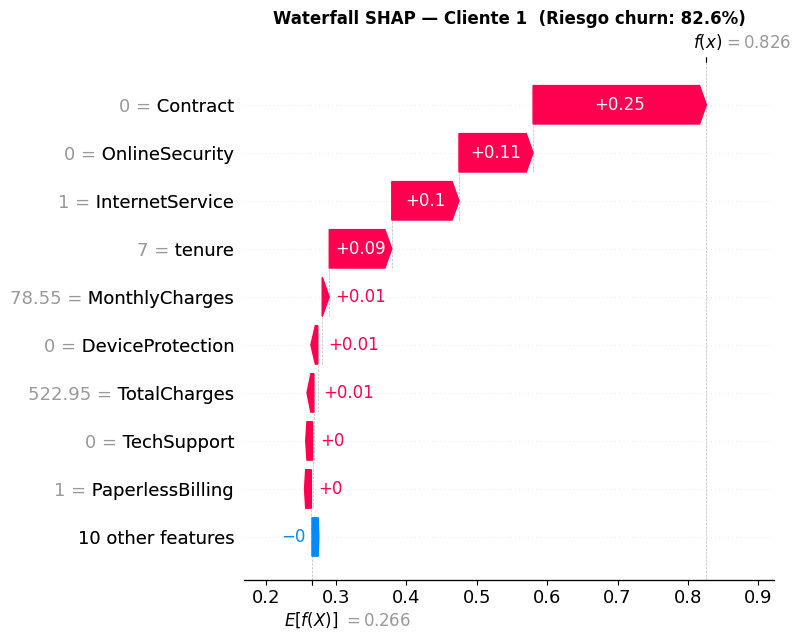


💡 Cómo leer el waterfall:
  E[f(x)] = predicción media del modelo para TODOS los clientes (base rate)
  f(x)    = predicción final para ESTE cliente concreto
  Barras ROJAS  → esta variable empuja hacia más churn
  Barras AZULES → esta variable empuja hacia menos churn


In [ ]:
# Waterfall plot — contribución de cada variable a esta predicción
base = explainer.expected_value
if isinstance(base, (list, np.ndarray)):
    base = base[1]

exp = shap.Explanation(
    values       = shap_churn[idx],
    base_values  = base,
    data         = X_test.iloc[idx].values,
    feature_names= FEATURES
)

plt.figure(figsize=(10, 5))
shap.plots.waterfall(exp, show=False)
plt.title(f'Waterfall SHAP — Cliente {idx}  (Riesgo churn: {prob_pred:.1%})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Cómo leer el waterfall:')
print('  E[f(x)] = predicción media del modelo para TODOS los clientes (base rate)')
print('  f(x)    = predicción final para ESTE cliente concreto')
print('  Barras ROJAS  → esta variable empuja hacia más churn')
print('  Barras AZULES → esta variable empuja hacia menos churn')

### 📊 10.3 Feature Importance — comparativa

Comparamos dos formas de medir la importancia de variables:
- **Gini Importance** (nativa del árbol): cuánto reduce el desorden cada variable
- **SHAP Importance** (|SHAP| medio): cuánto impacta cada variable en las predicciones

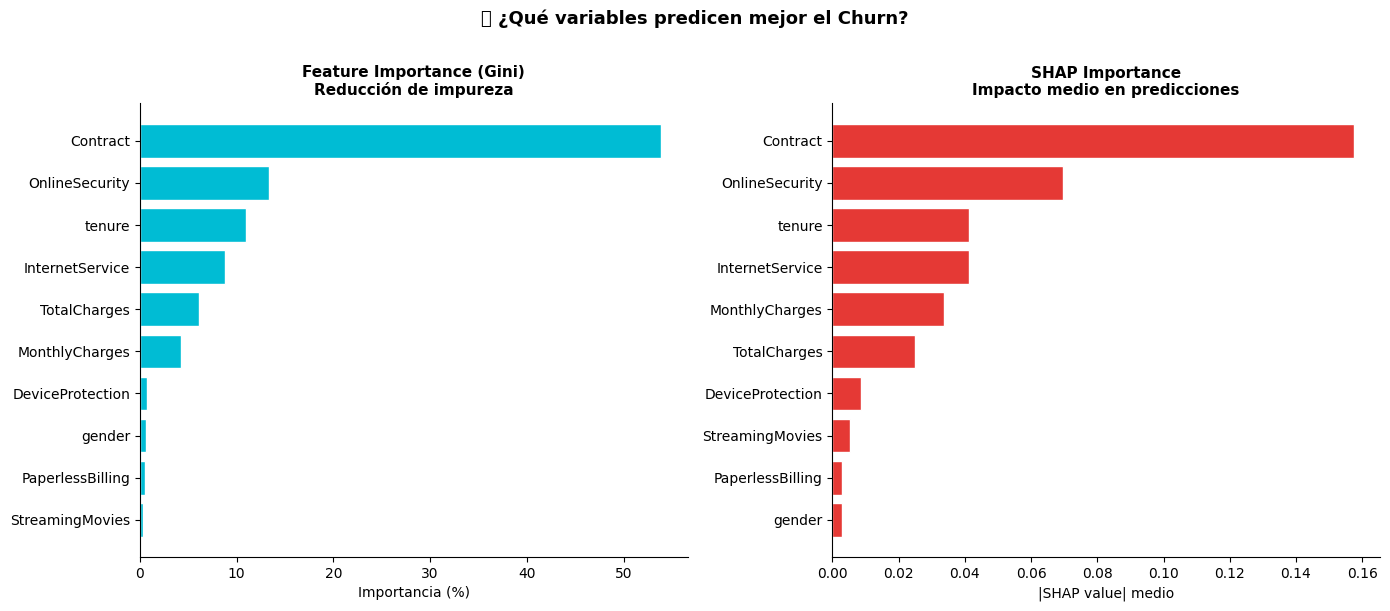


💡 Si los rankings son similares → buena señal, el modelo es consistente.
   Si difieren mucho → puede haber multicolinealidad (variables muy correladas).


In [ ]:
importances_gini = pd.Series(
    dt_optimo.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

importances_shap = pd.Series(
    np.abs(shap_churn).mean(axis=0),
    index=FEATURES
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Solo mostramos las top 10 para no saturar
top_n = 10
axes[0].barh(importances_gini.tail(top_n).index,
             importances_gini.tail(top_n).values * 100,
             color=C_NEUTRAL, edgecolor='white')
axes[0].set_title('Feature Importance (Gini)\nReducción de impureza',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Importancia (%)')

axes[1].barh(importances_shap.tail(top_n).index,
             importances_shap.tail(top_n).values,
             color=C_CHURN, edgecolor='white')
axes[1].set_title('SHAP Importance\nImpacto medio en predicciones',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('|SHAP value| medio')

plt.suptitle('🔍 ¿Qué variables predicen mejor el Churn?',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n💡 Si los rankings son similares → buena señal, el modelo es consistente.')
print('   Si difieren mucho → puede haber multicolinealidad (variables muy correladas).')

---
## 💼 11. Del modelo a las decisiones de negocio

Un modelo solo tiene valor si genera **acciones concretas**.
Vamos a transformar los resultados técnicos en recomendaciones para el equipo comercial.

In [ ]:
# Añadimos las probabilidades predichas al dataframe de test
df_resultado = X_test.copy()
df_resultado['prob_churn'] = y_prob_opt
df_resultado['churn_real'] = y_test.values

# Segmentación por nivel de riesgo
df_resultado['segmento_riesgo'] = pd.cut(
    df_resultado['prob_churn'],
    bins=[0, 0.30, 0.60, 1.0],
    labels=['Bajo  (<30%)', 'Medio (30-60%)', 'Alto  (>60%)']
)

seg = df_resultado.groupby('segmento_riesgo', observed=True).agg(
    clientes      = ('prob_churn', 'count'),
    churn_real_pct= ('churn_real', 'mean'),
    prob_media    = ('prob_churn', 'mean')
).round(3)

print('📊 SEGMENTACIÓN DE CLIENTES POR RIESGO')
print('=' * 55)
print(seg.to_string())
print()

# Variables top según SHAP
top3 = importances_shap.tail(3).index.tolist()[::-1]
print('📌 RECOMENDACIONES DE NEGOCIO (basadas en SHAP)')
print('-' * 55)
print()
n_alto = (df_resultado['segmento_riesgo'] == 'Alto  (>60%)').sum()
print(f'1. 🚨 ACCIÓN INMEDIATA')
print(f'   {n_alto} clientes con riesgo >60% → contacto proactivo en 48h')
print(f'   Ofrecer upgrade a contrato anual con descuento personalizado')
print()
print(f'2. 📄 CONTRATOS MENSUALES (variable más influyente según SHAP)')
monthly = df_resultado[df_resultado['Contract'] == 0]
print(f'   {len(monthly)} clientes en test tienen contrato mensual')
print(f'   → Campaña de migración a anual/bianual con incentivo económico')
print()
print(f'3. 🆕 ONBOARDING DE NUEVOS CLIENTES')
new = df_resultado[df_resultado['tenure'] <= 12]
print(f'   {len(new)} clientes con menos de 12 meses de antigüedad')
print(f'   → Programa de onboarding activo los primeros 6 meses (llamada proactiva, tutorial)')
print()
print(f'4. 🛡️ VENTA CRUZADA DE SERVICIOS DE SEGURIDAD')
print(f'   OnlineSecurity y TechSupport aparecen como factores protectores')
print(f'   → Clientes sin estos servicios tienen mayor riesgo → oferta de bundle')

📊 SEGMENTACIÓN DE CLIENTES POR RIESGO
                 clientes  churn_real_pct  prob_media
segmento_riesgo                                      
Bajo  (<30%)          845           0.115       0.103
Medio (30-60%)        307           0.423       0.451
Alto  (>60%)          226           0.646       0.717

📌 RECOMENDACIONES DE NEGOCIO (basadas en SHAP)
-------------------------------------------------------

1. 🚨 ACCIÓN INMEDIATA
   226 clientes con riesgo >60% → contacto proactivo en 48h
   Ofrecer upgrade a contrato anual con descuento personalizado

2. 📄 CONTRATOS MENSUALES (variable más influyente según SHAP)
   790 clientes en test tienen contrato mensual
   → Campaña de migración a anual/bianual con incentivo económico

3. 🆕 ONBOARDING DE NUEVOS CLIENTES
   451 clientes con menos de 12 meses de antigüedad
   → Programa de onboarding activo los primeros 6 meses (llamada proactiva, tutorial)

4. 🛡️ VENTA CRUZADA DE SERVICIOS DE SEGURIDAD
   OnlineSecurity y TechSupport aparecen co

---
## ✅ 12. Resumen

| Concepto | Lo esencial |
|---|---|
| **Árbol de decisión** | Secuencia de preguntas Si/No que el modelo aprende de los datos |
| **Índice Gini** | Mide el 'desorden' de un nodo — el árbol elige la pregunta que más lo reduce |
| **Overfitting** | Árbol sin límite memoriza el train y falla en datos nuevos |
| **`max_depth`** | El hiperparámetro más importante — controla la complejidad del árbol |
| **Curva de validación** | Herramienta para encontrar el `max_depth` óptimo visualmente |
| **Matriz de confusión** | TP, FP, FN, TN — no todos los errores tienen el mismo coste |
| **ROC-AUC** | Calidad del modelo independientemente del umbral de decisión |
| **SHAP** | Explica POR QUÉ el modelo hace cada predicción individual |

### Limitaciones del árbol de decisión
- ✅ Muy interpretable — se puede explicar a cualquier persona
- ✅ No necesita normalizar los datos
- ✅ Maneja datos mixtos (numéricos y categóricos)
- ❌ Overfitting fácil sin regularización
- ❌ Inestable — pequeños cambios en datos pueden dar árboles muy distintos
- ❌ Precisión limitada comparado con modelos ensemble

### ¿Qué viene a continuación?
```
Un árbol solo    →  Random Forest (100 árboles en paralelo → más robusto)
Random Forest    →  XGBoost       (árboles en secuencia → cada uno corrige al anterior)
```
> En el próximo notebook usaremos **este mismo dataset** para entrenar Random Forest
> y comparar directamente los resultados.

---
## 🏋️ Ejercicios para practicar

1. **Cambia el criterio** de `gini` a `entropy`. ¿Cambia mucho el resultado final?
2. **Prueba `min_samples_leaf=50`**. ¿El árbol mejora o empeora en test? ¿Por qué?
3. **Busca el cliente con MENOR riesgo** de churn y usa SHAP para explicar por qué.
   ```python
   idx_bajo = np.argmin(y_prob_opt)
   ```
4. **Observa en el árbol visual** cuál es la primera pregunta (raíz del árbol).
   ¿Coincide con la variable más importante según SHAP? ¿Qué concluyes?
5. **(Difícil)** Elimina la variable `Contract` del dataset y vuelve a entrenar.
   ¿Cuánto cae el AUC? ¿Qué variable 'toma el relevo' en el SHAP summary plot?